#  Инициализация весов нейронных сетей. Способы регуляризации нейронных сетей. Продвинутые алгоритмы градиентного спуска.

__Автор задач: Блохин Н.В. (NVBlokhin@fa.ru)__

Материалы:
* Deep Learning with PyTorch (2020) Авторы: Eli Stevens, Luca Antiga, Thomas Viehmann
* https://pytorch.org/docs/stable/nn.init.html
* https://machinelearningmastery.com/dropout-for-regularizing-deep-neural-networks/
* https://machinelearningmastery.com/batch-normalization-for-training-of-deep-neural-networks/
* https://pytorch.org/docs/stable/optim.html

## Задачи для совместного разбора

1\. Инициализируйте веса полносвязного слоя единицами, а смещения - нулями.

In [ ]:
import torch as th
import torch.nn as nn

In [ ]:
fc = nn.Linear(in_features=10, out_features=5)
fc

Linear(in_features=10, out_features=5, bias=True)

In [ ]:
fc.weight

Parameter containing:
tensor([[-0.1580,  0.0507, -0.2042, -0.0459,  0.1456,  0.0072, -0.0591, -0.2199,
          0.0142, -0.0092],
        [ 0.2882,  0.2565,  0.2624, -0.1088, -0.1963,  0.1869,  0.2569,  0.1279,
          0.0489,  0.2343],
        [-0.0727,  0.0601, -0.1498, -0.1560,  0.2106,  0.1388, -0.1470, -0.1707,
          0.1391, -0.0548],
        [ 0.2930, -0.0127, -0.2827, -0.1935, -0.2536,  0.0246, -0.1884, -0.1918,
         -0.1758, -0.0951],
        [ 0.0048,  0.3011,  0.0536,  0.1461,  0.2575, -0.2631, -0.2595, -0.2413,
          0.2133, -0.1943]], requires_grad=True)

In [ ]:
fc.bias

Parameter containing:
tensor([ 0.1175, -0.2406,  0.3041, -0.0411, -0.2382], requires_grad=True)

In [ ]:
# fc.weight = th.ones_like(fc.weight)

In [ ]:
fc.weight.data = th.ones_like(fc.weight)

In [ ]:
nn.init.ones_(fc.weight)

Parameter containing:
tensor([[1., 1., 1., 1., 1., 1., 1., 1., 1., 1.],
        [1., 1., 1., 1., 1., 1., 1., 1., 1., 1.],
        [1., 1., 1., 1., 1., 1., 1., 1., 1., 1.],
        [1., 1., 1., 1., 1., 1., 1., 1., 1., 1.],
        [1., 1., 1., 1., 1., 1., 1., 1., 1., 1.]], requires_grad=True)

In [ ]:
fc.weight

Parameter containing:
tensor([[1., 1., 1., 1., 1., 1., 1., 1., 1., 1.],
        [1., 1., 1., 1., 1., 1., 1., 1., 1., 1.],
        [1., 1., 1., 1., 1., 1., 1., 1., 1., 1.],
        [1., 1., 1., 1., 1., 1., 1., 1., 1., 1.],
        [1., 1., 1., 1., 1., 1., 1., 1., 1., 1.]], requires_grad=True)

2\. Изучите, как работает слой `nn.Dropout` в режиме обучения модели и в режиме использования модели.

In [ ]:
from sklearn.datasets import make_regression
import torch as th

X, y, coef = make_regression(n_features=4, n_informative=4, coef=True, bias=0.5, random_state=42)
X = th.FloatTensor(X)
y = th.FloatTensor(y).reshape(-1, 1)

In [ ]:
fc1 = nn.Linear(in_features=4, out_features=10)
relu = nn.ReLU()
fc2 = nn.Linear(in_features=10, out_features=1)
# ...

out = fc1(X)
out = relu(out)
out = fc2(out)
# ...

In [ ]:
class FullyConnectedNet(nn.Module):
  def __init__(self, n_inputs, n_hidden, n_out):
    super().__init__() # вызываем конструктор у родителя
    self.fc1 = nn.Linear(in_features=n_inputs, out_features=n_hidden)
    self.relu = nn.ReLU()
    self.fc2 = nn.Linear(in_features=n_hidden, out_features=n_out)

  def forward(self, X):
    out = self.fc1(X)
    out = self.relu(out)
    out = self.fc2(out)
    return out

In [ ]:
n_inputs, n_hidden, n_out = 4, 10, 1

net = nn.Sequential(
    nn.Linear(in_features=n_inputs, out_features=n_hidden),
    nn.ReLU(),
    nn.Linear(in_features=n_hidden, out_features=n_out)
)

In [ ]:
net = FullyConnectedNet(n_inputs=4, n_hidden=10, n_out=1)
out = net(X)

In [ ]:
net

FullyConnectedNet(
  (fc1): Linear(in_features=4, out_features=10, bias=True)
  (relu): ReLU()
  (fc2): Linear(in_features=10, out_features=1, bias=True)
)

In [ ]:
net.parameters()

<generator object Module.parameters at 0x7bbbda1435a0>

In [ ]:
net(X)

tensor([[ 0.1734],
        [ 0.0574],
        [ 0.2799],
        [ 0.2602],
        [ 0.4340],
        [ 0.4038],
        [-0.3081],
        [ 0.1915],
        [ 0.4817],
        [ 0.3917],
        [ 0.3922],
        [ 0.1523],
        [ 0.3634],
        [ 0.3375],
        [ 0.5431],
        [ 0.2083],
        [ 0.5397],
        [ 0.3433],
        [ 0.4832],
        [ 0.4211],
        [-0.1745],
        [ 0.3720],
        [ 0.4416],
        [ 0.3210],
        [-0.0707],
        [ 0.3724],
        [ 0.2668],
        [ 0.4350],
        [ 0.3587],
        [ 0.3142],
        [ 0.4468],
        [ 0.3667],
        [ 0.0747],
        [ 0.3753],
        [ 0.2505],
        [ 0.3578],
        [ 0.2329],
        [ 0.2928],
        [ 0.1620],
        [ 0.1668],
        [ 0.3847],
        [ 0.3460],
        [ 0.6307],
        [ 0.3256],
        [ 0.5489],
        [ 0.3123],
        [ 0.4882],
        [ 0.3958],
        [ 0.3288],
        [ 0.3225],
        [ 0.3176],
        [ 0.4670],
        [ 0.

In [ ]:
dropout = nn.Dropout(p=0.5)

In [ ]:
X = th.randn(size=(5, 5))
X

tensor([[-0.1976,  0.3258, -0.0566, -1.3929,  0.0817],
        [ 0.2416,  1.2083,  0.7275,  0.2615, -0.2685],
        [ 1.3558,  0.2548,  1.0846, -0.1103, -1.0007],
        [-0.0297,  0.4720,  1.9068,  0.5495, -1.4321],
        [ 1.6469,  0.5817, -1.1933,  0.6292,  0.5314]])

In [ ]:
dropout(X)

tensor([[-0.3952,  0.0000, -0.0000, -0.0000,  0.0000],
        [ 0.0000,  2.4166,  1.4550,  0.5231, -0.0000],
        [ 0.0000,  0.5096,  0.0000, -0.0000, -2.0014],
        [-0.0595,  0.9439,  3.8136,  0.0000, -0.0000],
        [ 0.0000,  0.0000, -2.3866,  1.2585,  1.0629]])

In [ ]:
dropout.eval()

Dropout(p=0.5, inplace=False)

In [ ]:
dropout(X)

tensor([[-0.1976,  0.3258, -0.0566, -1.3929,  0.0817],
        [ 0.2416,  1.2083,  0.7275,  0.2615, -0.2685],
        [ 1.3558,  0.2548,  1.0846, -0.1103, -1.0007],
        [-0.0297,  0.4720,  1.9068,  0.5495, -1.4321],
        [ 1.6469,  0.5817, -1.1933,  0.6292,  0.5314]])

In [ ]:
dropout.train()

Dropout(p=0.5, inplace=False)

In [ ]:
dropout(X)

tensor([[-0.3952,  0.0000, -0.1133, -2.7859,  0.1633],
        [ 0.0000,  2.4166,  0.0000,  0.0000, -0.5370],
        [ 2.7116,  0.0000,  0.0000, -0.2206, -2.0014],
        [-0.0000,  0.9439,  0.0000,  1.0991, -2.8641],
        [ 0.0000,  1.1634, -0.0000,  0.0000,  1.0629]])

In [ ]:
class FullyConnectedNet(nn.Module):
  def __init__(self, n_inputs, n_hidden, n_out, p=0.5):
    super().__init__() # вызываем конструктор у родителя
    self.fc1 = nn.Linear(in_features=n_inputs, out_features=n_hidden)
    self.relu = nn.ReLU()
    self.fc2 = nn.Linear(in_features=n_hidden, out_features=n_out)
    self.dropout = nn.Dropout(p=p)

  def forward(self, X):
    out = self.fc1(X)
    out = self.relu(out)
    out = self.dropout(out)
    out = self.fc2(out)
    return out

In [ ]:
net = FullyConnectedNet(n_inputs=4, n_hidden=10, n_out=1, p=0.2)
# net.eval()
# out = net(X)

3\. Изучите, как работает слой `nn.BatchNorm1d` в режиме обучения модели и в режиме использования модели.

In [ ]:
bn = nn.BatchNorm1d(num_features=4)

In [ ]:
X.shape

torch.Size([5, 5])

In [ ]:
# out = bn(X)
out.mean(dim=0), out.std(dim=0)

(tensor([0.3231], grad_fn=<MeanBackward1>),
 tensor([0.1553], grad_fn=<StdBackward0>))

In [ ]:
bn.running_mean

tensor([0., 0., 0., 0.])

In [ ]:
bn.running_var

tensor([1., 1., 1., 1.])

In [ ]:
bn.eval()

BatchNorm1d(4, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)

In [ ]:
class FullyConnectedNet(nn.Module):
  def __init__(self, n_inputs, n_hidden, n_out, p=0.5):
    super().__init__() # вызываем конструктор у родителя
    self.fc1 = nn.Linear(in_features=n_inputs, out_features=n_hidden)
    self.relu = nn.ReLU()
    self.fc2 = nn.Linear(in_features=n_hidden, out_features=n_out)
    self.bn1 = nn.BatchNorm1d(num_features=n_hidden)

  def forward(self, X):
    out = self.fc1(X)
    out = self.bn1(out)
    out = self.relu(out)
    # out = self.bn1(out)
    out = self.fc2(out)
    #
    return out

## Задачи для самостоятельного решения

<p class="task" id="1"></p>

1\. Расширьте класс `torch.nn.Linear`, описав класс `InitializedLinear` и добавив возможность инициализировать веса слоя при помощи функций из пакета `torch.nn.init`. Обратите внимание, что данные функции имеют дополнительные параметры. Данные параметры должны передаваться в момент создания объекта класса `InitializedLinear`.

Пример создания слоя:
```
InitializedLinear(n_features, n_hidden, init_f=nn.init.uniform_, init_args={"a": 0.0, "b": 1.0})
```

- [ ] Проверено на семинаре

In [ ]:
class InitializedLinear(nn.Module):
  def __init__(self, n_features, n_hidden, init_f, init_args = {}):
    super().__init__() # вызываем конструктор у родителя
    self.fc = nn.Linear(in_features=n_features, out_features=n_hidden)
    init_f(self.fc.weight, **init_args)

In [ ]:
model = InitializedLinear(n_features = 2, n_hidden = 2 , init_f=nn.init.uniform_, init_args={"a": 0.0, "b": 1.0})
model.fc.weight

Parameter containing:
tensor([[0.7463, 0.5844],
        [0.8405, 0.1796]], requires_grad=True)

<p class="task" id="2"></p>

2\. Решите задачу регрессии несколько раз, изменяя способ инициализации весов. Рассмотрите следующие варианты:
* `nn.init.uniform_`
* `nn.init.normal_`
* `nn.init.constant_`
* `nn.xavier_uniform_`
* `nn.kaiming_uniform_`

Визуализируйте график изменения значений MSE с ходом эпох. Дайте кривым, соответствующие разным способам инициализации, различные цвета и добавьте подписи. Для улучшения читаемости графиков можно рассматривать области экстремальных значений отдельно.

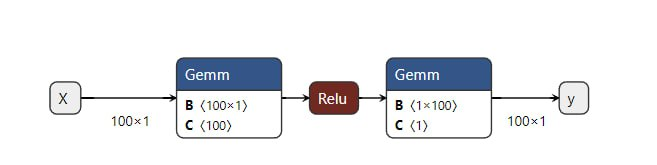
- [ ] Проверено на семинаре

In [ ]:
import torch as th
X = th.linspace(0, 1, 100).view(-1, 1)
y = th.sin(2 * th.pi * X) + 0.1 * th.rand(X.size())
X.shape

torch.Size([100, 1])

In [ ]:
class InitializedLinear(nn.Module):
  def __init__(self, n_features, n_hidden,n_out, init_f, init_args = {}):
    super().__init__() # вызываем конструктор у родителя
    self.fc1 = nn.Linear(in_features=n_features, out_features=n_hidden)
    self.fc1.weight = init_f(self.fc1.weight, **init_args)
    self.relu = nn.ReLU()
    self.fc2 = nn.Linear(in_features=n_hidden, out_features=n_out)
    self.fc2.weight = init_f(self.fc2.weight, **init_args)

  def forward(self, inputs):
    out = self.fc1(inputs)
    out = self.relu(out)
    out = self.fc2(out)
    return out

In [ ]:
init = {
    nn.init.uniform_: {'a':0, 'b':1} ,   # равномерное распределение
    nn.init.normal_ : {'mean': 0, 'std': 1},   # норм распределение
    nn.init.constant_ : {'val': 0.5},   # заполнение константой
    nn.init.xavier_uniform_: {'gain': 1.0},
    nn.init.kaiming_uniform_ : {'a':0, 'mode':'fan_in', 'nonlinearity':'relu'}
}

In [ ]:
model = InitializedLinear(n_features = X.shape[1], n_hidden = 1,n_out = 1, init_f = nn.init.uniform_, init_args = {'a':0, 'b':1})
model

InitializedLinear(
  (fc1): Linear(in_features=1, out_features=1, bias=True)
  (relu): ReLU()
  (fc2): Linear(in_features=1, out_features=1, bias=True)
)

In [ ]:
import torch.optim as optim
from collections import defaultdict

In [ ]:
criterion = nn.MSELoss()
n_epochs = 1000

loss_res = defaultdict(list)
keys = [
'uniform_',
'normal_ ',
'constant_',
'xavier_uniform_',
'kaiming_uniform_'
]


for (i, j), k in zip(init.items(), keys):
    neuron = InitializedLinear(n_features = X.shape[1], n_hidden = 1,n_out = 1, init_f = i, init_args = j)
    optimizer = optim.SGD(neuron.parameters(), lr=0.001)

    for epoch in range(n_epochs):

      out = neuron.forward(X)
      loss = criterion(out, y)
      # 2. backprop
      loss.backward()
      # 3. gradient descend
      optimizer.step()

      loss_res[k].append(loss.item())
      # 4. zero grads
      optimizer.zero_grad()
# loss_res

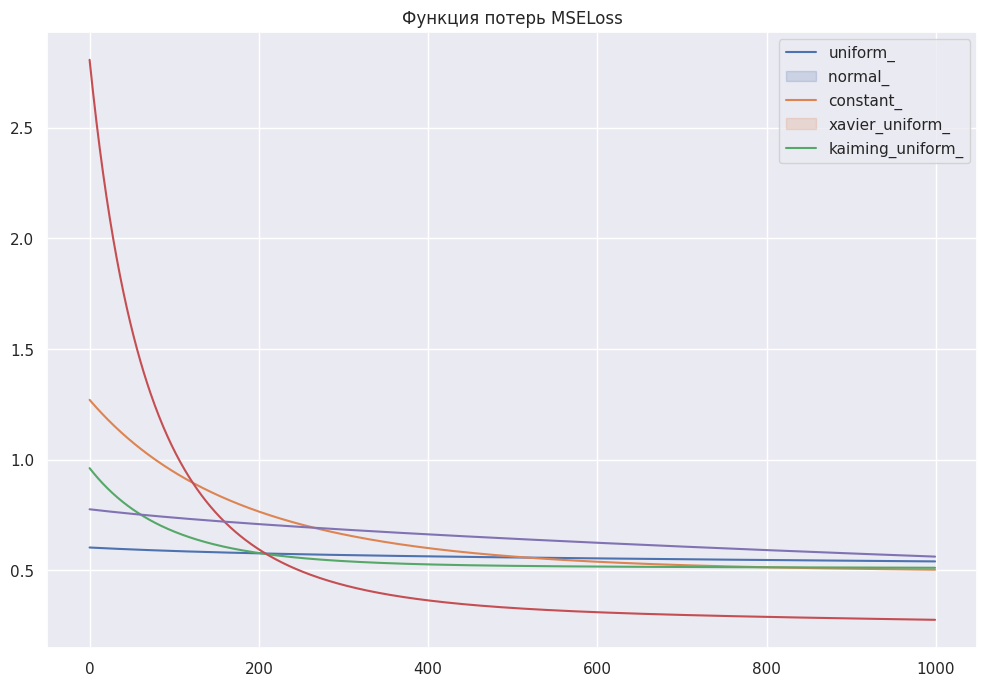

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.set(rc={'figure.figsize':(12,8)})
for mse in loss_res:
  graph = sns.lineplot(loss_res[mse])
  graph.set_title('Функция потерь MSELoss')
  plt.legend(keys)

<p class="task" id="3"></p>

3\. Исследуйте, как добавление дропаута влияет на процесс обучения модели. Решите задачу регрессии несколько раз, изменяя значения вероятности дропаута $p$ от 0 до 0.8. В качестве модели рассмотрите нейронную сеть с одним скрытым слоем.

Визуализируйте график изменения значений $R^2$ в зависимости от вероятности дропаута $p$ на обучающей и тестовой выборке. Визуализируйте на отдельном графике зависимости разности между $R^2$ на обучающей выборки и $R^2$ на тестовой выборке.

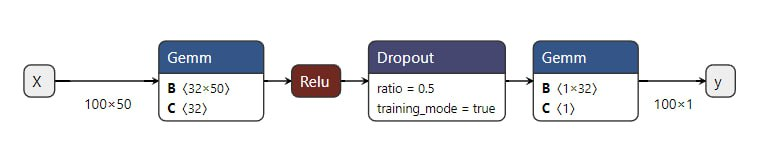

- [ ] Проверено на семинаре

In [ ]:
from sklearn.datasets import make_regression
import torch as th
from sklearn.metrics import r2_score

th.manual_seed(42)
X, y, coef = make_regression(
    n_samples=100,
    n_features=50,
    n_informative=20,
    noise=2,
    coef=True,
    random_state=42,

)
X = th.FloatTensor(X)
y = th.FloatTensor(y).reshape(-1, 1)
X.shape

torch.Size([100, 50])

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    train_size = 0.8,
    random_state = 42
)

In [ ]:
p = th.arange(0, 0.9, 0.1)
p

tensor([0.0000, 0.1000, 0.2000, 0.3000, 0.4000, 0.5000, 0.6000, 0.7000, 0.8000])

In [ ]:
# class FullyConnectedNet(nn.Module):
#   def __init__(self, n_inputs, n_hidden, n_out, p):
#     super().__init__() # вызываем конструктор у родителя
#     self.fc1 = nn.Linear(in_features=n_inputs, out_features=n_hidden)
#     self.relu = nn.ReLU()
#     self.dropout = nn.Dropout(p=p)
#     self.fc2 = nn.Linear(in_features=n_hidden, out_features=n_out)

#   def forward(self, X):
#     out = self.fc1(X)
#     out = self.relu(out)
#     out = self.dropout(out)
#     out = self.fc2(out)
#     return out

In [ ]:
# neuron = FullyConnectedNet(n_inputs=X.shape[1], n_hidden=32, n_out=1, p=0.2)
# neuron.eval()
# # out = net(X)


In [ ]:
n_epochs = 500
criterion = nn.MSELoss()
r2_train = []
r2_test = []

for p_ in p:
  neuron = nn.Sequential(
          nn.Linear(X_train.shape[1], 32),
          nn.ReLU(),
          nn.Dropout(p_),
          nn.Linear(32, 1)
      )

  for epochs in range(n_epochs):
    train_out = neuron.forward(X_train)
    train_loss = criterion(train_out, y_train)
    train_loss.backward()

    optimizer.step()
    optimizer.zero_grad()
    # print(f"{epochs=} {train_loss.item()=}")

    with th.no_grad():
      test_out = neuron.forward(X_test)
      test_loss = criterion(test_out, y_test)

  r2_train.append(r2_score(y_train.numpy(), train_out.detach().numpy()))
  r2_test.append(r2_score(y_test.numpy(), test_out.numpy()))

Text(0.5, 1.0, 'На обучающей выборке')

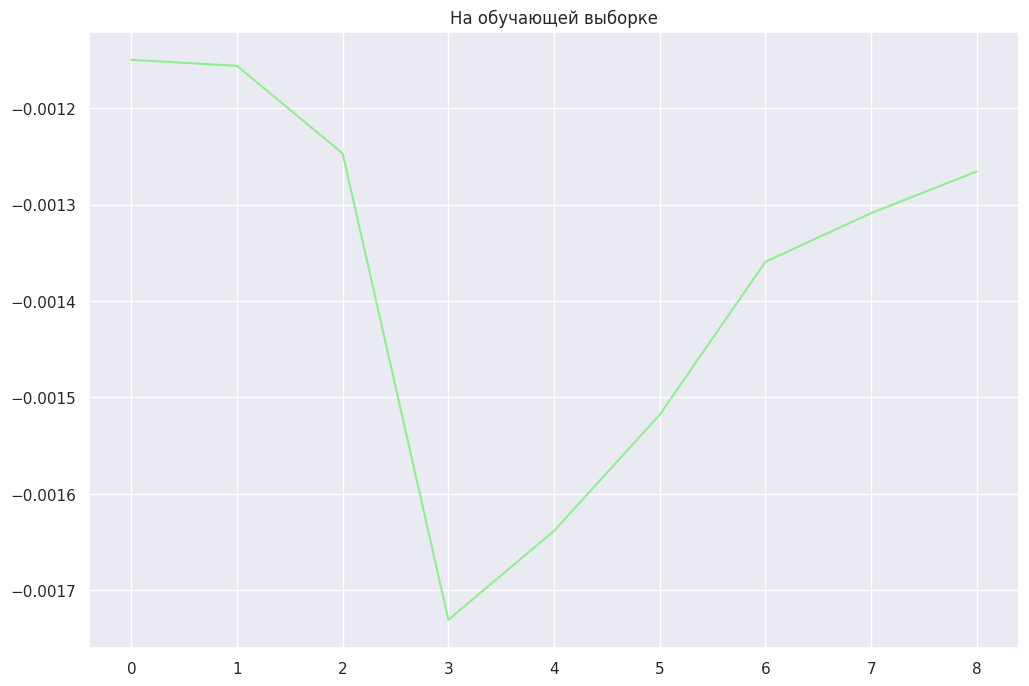

In [ ]:
sns.lineplot(r2_train, color = 'lightgreen').set_title('На обучающей выборке')

Text(0.5, 1.0, 'На тестовой выборке')

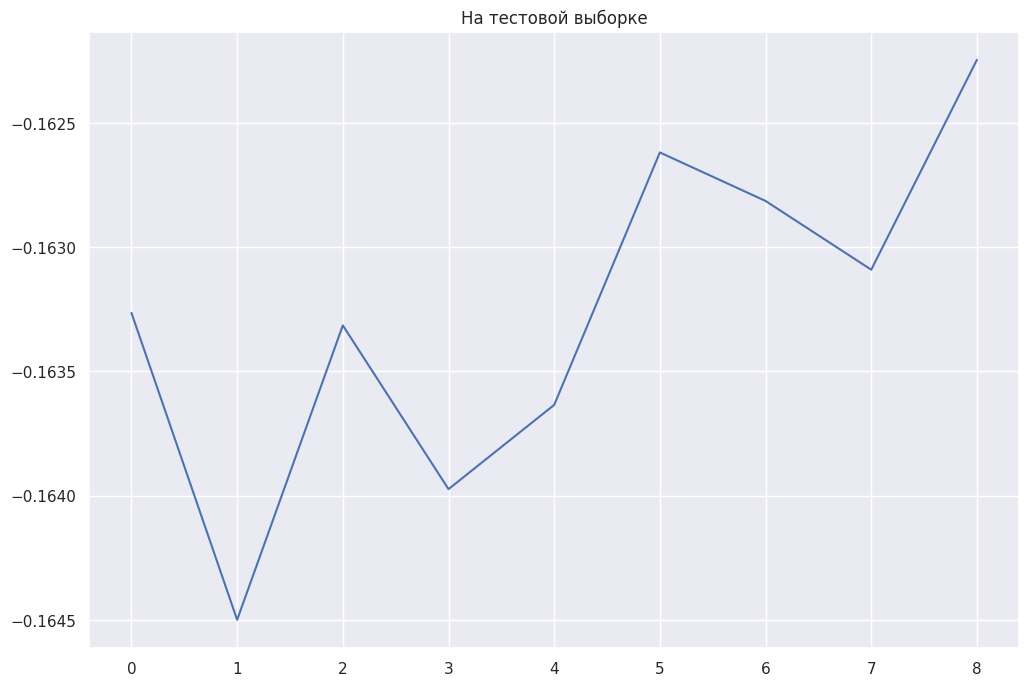

In [ ]:
sns.lineplot(r2_test).set_title('На тестовой выборке')

Text(0.5, 1.0, 'Разница')

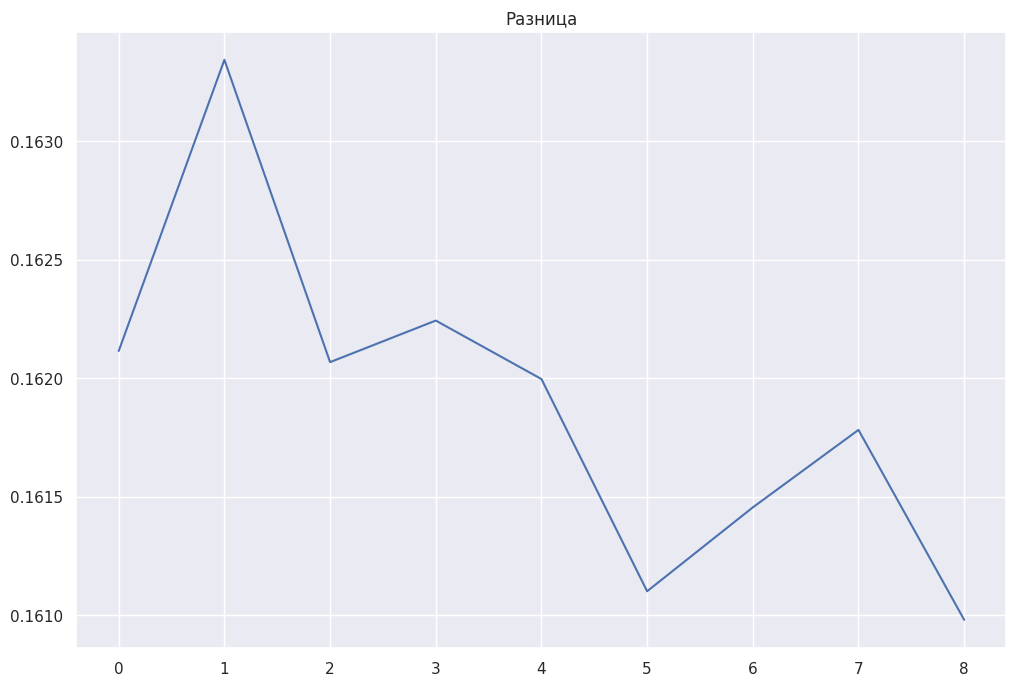

In [ ]:
import numpy as np
sns.lineplot(np.array(r2_train) - np.array(r2_test)).set_title('Разница')

<p class="task" id="4"></p>

4\. Решите задачу регрессии с- и без использования пакетной нормализации. Покажите, как меняется результат обучения моделей при различных значениях скорости обучения (0.001, 0.01, 0.1) за одно и то же количество эпох.

Визуализируйте график изменения значений $R^2$ в зависимости от эпохи при различных значениях скорости обучения с- и без использования пакетной нормализации.

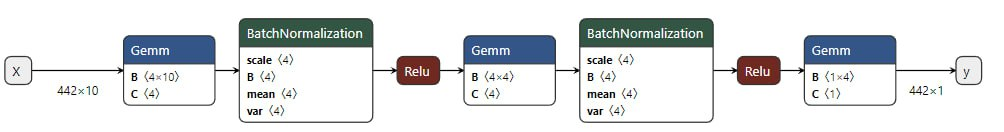

- [ ] Проверено на семинаре

In [ ]:
from sklearn.datasets import load_diabetes

X, y = load_diabetes(return_X_y=True)
X = th.FloatTensor(X)
y = th.FloatTensor(y).reshape(-1, 1)
y = (y - y.mean())/y.std()
X.shape

torch.Size([442, 10])

In [ ]:
learning_rate = [0.001, 0.01, 0.1]

In [ ]:
neuron = nn.Sequential(
    nn.Linear(X.shape[1], 4),
    nn.BatchNorm1d(num_features=4),
    nn.ReLU(),
    nn.Linear(4,4),
    nn.BatchNorm1d(num_features=4),
    nn.ReLU(),
    nn.Linear(4,1)
)

In [ ]:
criterion = nn.MSELoss()
r2_res = defaultdict(list)
for i in learning_rate:
  optimizer = optim.SGD(neuron.parameters(), lr = i)

  for epoch in range(n_epochs):
    out = neuron(X)
    loss = criterion.forward(out, y)

    loss.backward()
    optimizer.step()
    optimizer.zero_grad()


    r2_res[i].append(r2_score(y.detach().numpy(), out.detach().numpy()))
# r2

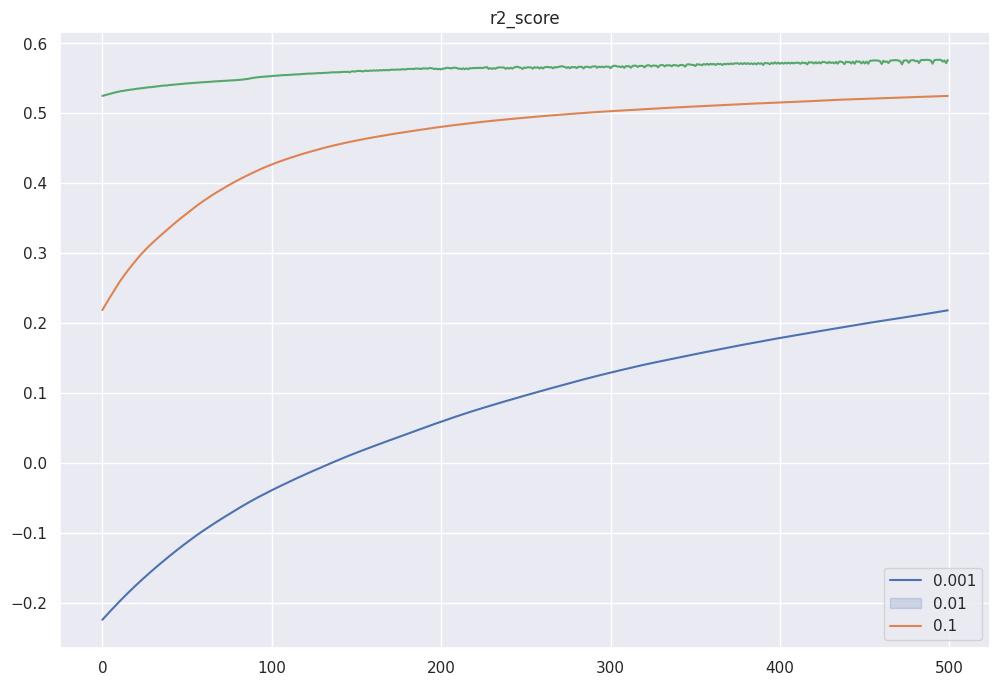

In [ ]:
for r2 in r2_res:
  graph = sns.lineplot(r2_res[r2])
  graph.set_title('r2_score')
  plt.legend(learning_rate)

<p class="task" id="5"></p>

5\. Решите задачу регрессии c использованием различных алгоритмов градиентного спуска. Покажите, как меняется результат обучения моделей при использовании различных алгоритмов (Adam, Adagram, RMSProp, SGD) за одно и то же количество эпох с одной и той же скоростью обучения.

Визуализируйте график изменения значений MAPE в зависимости от эпохи при использовании различных алгоритмов градиентного спуска.
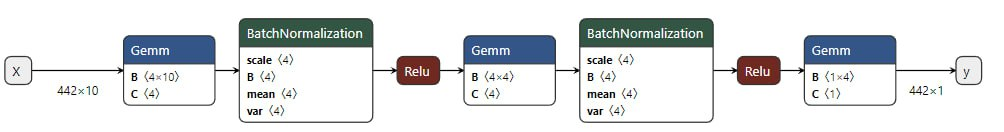

- [ ] Проверено на семинаре

In [ ]:
def load_boston():
    import pandas as pd
    import numpy as np

    data_url = "http://lib.stat.cmu.edu/datasets/boston"
    raw_df = pd.read_csv(data_url, sep="\s+", skiprows=22, header=None)
    data = np.hstack([raw_df.values[::2, :], raw_df.values[1::2, :2]])
    target = raw_df.values[1::2, 2]
    return data, target

In [ ]:
X, y = load_boston()
X = th.FloatTensor(X)
y = th.FloatTensor(y).reshape(-1, 1)
X.shape

torch.Size([506, 13])

In [ ]:
from sklearn.metrics import mean_absolute_percentage_error

In [ ]:
alg = {
    'Adam':  optim.Adam(neuron.parameters(), lr = 0.01),
    'Adagrad':  optim.Adagrad(neuron.parameters(), lr = 0.01),
    'RMSProp': optim.RMSprop(neuron.parameters(), lr = 0.01),
    'SGD': optim.SGD(neuron.parameters(), lr = 0.01)
}

neuron = nn.Sequential(
    nn.Linear(X.shape[1], 4),
    nn.BatchNorm1d(num_features=4),
    nn.ReLU(),
    nn.Linear(4,4),
    nn.BatchNorm1d(num_features=4),
    nn.ReLU(),
    nn.Linear(4,1)
)

In [ ]:
criterion = nn.MSELoss()
n_epochs = 500

mape_res = defaultdict(list)


for i in alg:

  optimizer = alg[i]

  for epoch in range(n_epochs):
      out = neuron.forward(X)
      loss = criterion.forward(out, y)

      loss.backward()
      optimizer.step()
      optimizer.zero_grad()


      mape_res[i].append(mean_absolute_percentage_error(y.detach().numpy(), out.detach().numpy()))
# mape_res


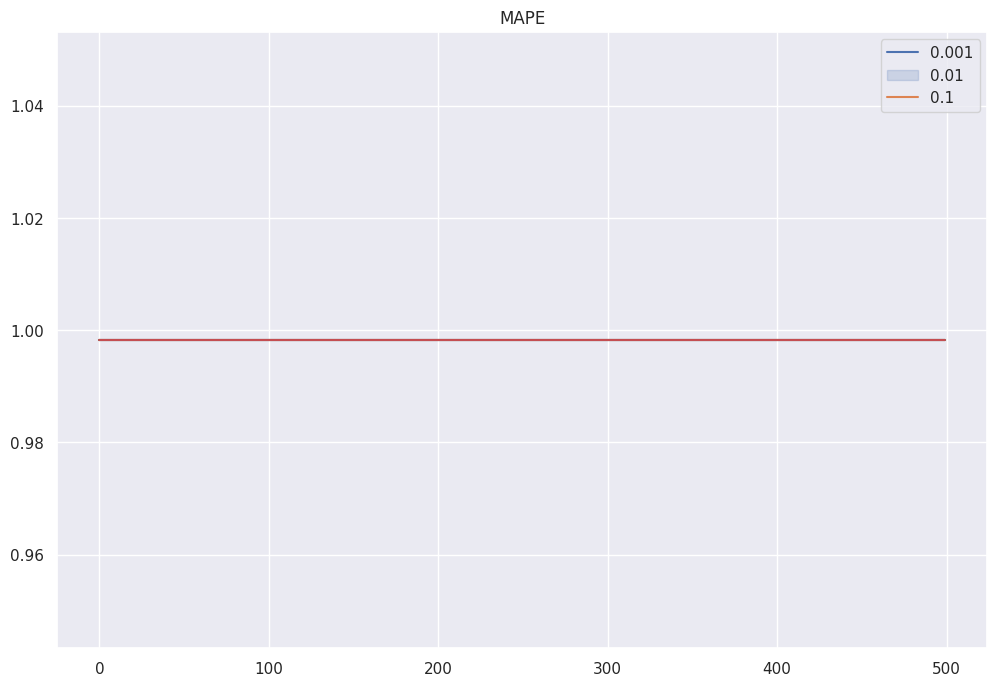

In [ ]:
for mape in mape_res:
  graph = sns.lineplot(mape_res[mape])
  graph.set_title('MAPE')
  plt.legend(learning_rate)

<p class="task" id="6"></p>

6\. Решите задачу регрессии c использованием ранней остановки. Разбейте набор данных на обучающую и валидационную выборку в соотношении 80 на 20. Остановите процесс обучения, если целевая метрика (MAPE) не увеличивалась в течении последних $k$ ($k$ - гиперпараметр метода) эпох. В момент остановки выведите сообщение с текущим номером эпохи.

- [ ] Проверено на семинаре

In [ ]:
X, y = load_boston()
X = th.FloatTensor(X)
y = th.FloatTensor(y).reshape(-1, 1)

In [ ]:
X_train, X_val, y_train, y_val = train_test_split(
    X,y,
    train_size = 0.8,
    random_state = 42
)

## Обратная связь
- [ ] Хочу получить обратную связь по решению